In [30]:
# features
# - TEMA
# - EMA4, 9, 18 crossover
# - False Breakout Finder (*new intraday high, close lower than previous high, new intraday low, close higher than previous low
# - ATR
# - Relative Strength Analysis
# - market breadth (indicator of overall market performance)
# - skdj

import investpy
import pandas as pd
import numpy as np
import yfinance as yf
from itertools import combinations
import ta

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.metrics import roc_auc_score

In [31]:
# def download_data(ticker: str):
#     df = yf.download(ticker, period="10y", interval="1d", multi_level_index=False)
#     df.dropna(inplace=True)
#     return df

def calculate_indicators(df, close, high, low, vol):
    df['RSI'] = ta.momentum.RSIIndicator(df[close]).rsi()

    macd = ta.trend.MACD(df[close])
    df['MACD'] = macd.macd()
    df['MACD_Signal'] = macd.macd_signal()
    df['MACD_Hist'] = macd.macd_diff()

    df['ATR'] = ta.volatility.AverageTrueRange(df[high], df[low], df[close]).average_true_range()

    df['TEMA'] = ta.trend.EMAIndicator(df[close], window=30).ema_indicator()
    df['EMA4'] = ta.trend.EMAIndicator(df[close], window=4).ema_indicator()
    df['EMA9'] = ta.trend.EMAIndicator(df[close], window=9).ema_indicator()
    df['EMA18'] = ta.trend.EMAIndicator(df[close], window=18).ema_indicator()

    df['OBV'] = ta.volume.OnBalanceVolumeIndicator(df[close], df[vol], fillna=True).on_balance_volume()
    df['VWAP'] = ta.volume.VolumeWeightedAveragePrice(df[high], df[low], df[close], df[vol], fillna=True).volume_weighted_average_price()
    # df['EMA4_Crossover_up'] = (df['EMA4'] > df['EMA9']) & (df['EMA9'] > df['EMA18'])
    # df['EMA4_Crossover_down'] = (df['EMA4'] < df['EMA9']) & (df['EMA9'] < df['EMA18'])

    stoch = ta.momentum.StochasticOscillator(df[high], df[low], df[close])
    df['SKDJ_K'] = stoch.stoch()
    df['SKDJ_D'] = stoch.stoch_signal()

    return df

def calculate_flags(df, high, low, close):
    df['Max_High'] = df[high].rolling(window=12).max().shift(-12)
    df['Min_Low'] = df[low].rolling(window=12).min().shift(-12)
    df['Flag'] = df.apply(lambda row:  2 if (row['Max_High'] > 1.005*row[close] and row['Min_Low'] < 0.995*row[close])
                                        else ((1 if row['Max_High'] > 1.005*row[close]
                                        else (-1 if row['Min_Low'] < 0.995*row[close]
                                        else 0))), axis=1)
    return df

def get_all_ratios(df, exclusion_list):
    feature_list = [col for col in df.columns.tolist() if col not in exclusion_list]
    new_columns = []
    for feat1, feat2 in combinations(feature_list, 2):
        column_name = f"{feat1}/{feat2}"
        new_columns.append((column_name, df[feat1] / df[feat2]))

    new_columns_df = pd.DataFrame(dict(new_columns))
    df = pd.concat([df, new_columns_df], axis=1)
    return df

def get_past_daily_ret(df, close):
    past_prices = []
    for i in range(0,30):
        column_name = f"Return_{i}"
        past_prices.append((column_name, df[close].shift(i)/df[close].shift(i+1)-1))
    past_prices_df = pd.DataFrame(dict(past_prices))
    df = pd.concat([df, past_prices_df], axis=1)
    return df


# def calculate_relative_strength(df, market):
#     df_market = yf.download(market, period="10y", interval="1d", multi_level_index=False)['Close'].rename(market)
#     df['market_close'] = df.merge(df_market, how='left', left_index=True, right_index=True)[market]
#     df['relative_strength'] = df['Close']/df['market_close']
#     df['relative_strength_EMA_4'] = ta.trend.EMAIndicator(df['relative_strength'], window=4).ema_indicator()
#     df['relative_strength_EMA_9'] = ta.trend.EMAIndicator(df['relative_strength'], window=9).ema_indicator()
#     return df

# def data_prep(ticker, market):
#     df = download_data(ticker)
#     df = calculate_indicators(df)
#     df = calculate_flags(df)
#     df = calculate_relative_strength(df, market)
#     df.drop(columns=['Max_High_2w', 'Min_Low_2w'], inplace=True)  # Clean up unnecessary columns
#     df.dropna(inplace=True)

    # return df
    # df.to_csv(f'{ticker}_processed.csv')
    # print(f'Data saved to {ticker}_processed.csv')

In [32]:
df =  pd.read_csv('Data/AUDNZD/AUDNZD_H1_201401012300_202504010800.csv', delimiter='\t',engine='python')
# df_iron = pd.read_csv('Data/AUDNZD/PIORECRUSDM.csv')
df['Date'] = pd.to_datetime(df['<DATE>'], format='%Y.%m.%d')
df['datetime'] = pd.to_datetime(df['<DATE>'] + ' ' + df['<TIME>'], format='%Y.%m.%d %H:%M:%S')
df['time'] = pd.to_datetime(df['<TIME>'], format='%H:%M:%S').dt.hour
df = calculate_indicators(df, '<CLOSE>', '<HIGH>', '<LOW>', '<TICKVOL>')
df = get_all_ratios(df, ['<DATE>','time','<TIME>','datetime','Date','<VOL>'])
df = get_past_daily_ret(df, '<CLOSE>')
df = calculate_flags(df,'<HIGH>','<LOW>','<CLOSE>')

In [33]:
df.set_index('datetime', inplace=True)

In [34]:
df['Flag'].value_counts()

Flag
 0    60044
-1     5120
 1     4666
 2      121
Name: count, dtype: int64

In [29]:
df

Series([], Name: proportion, dtype: float64)

### Decision Tree Model

In [9]:
# Sort data by Date
df = df.sort_index()

# Split the data into train and test (20% test data)
# Define train-test split with a gap of 20 data points
train_size = int(0.8 * len(df))
train_data = df.iloc[:train_size].replace([np.inf, -np.inf], np.nan).dropna()
test_data = df.iloc[train_size + 100:].replace([np.inf, -np.inf], np.nan).dropna()  # Skipping 20 rows

# Features (excluding 'Date' and 'Flag' columns)
exclusion_list = ['datetime','<TIME>','Date','<DATE>','<VOL>','Flag','Max_High','Min_Low']
features = [col for col in df.columns.tolist() if col not in exclusion_list]

X_train = train_data[features]
y_train = train_data['Flag']==-1

X_test = test_data[features]
y_test = test_data['Flag']==-1

# 2) Logistic Regression with SequentialFeatureSelector and Cross-validation

# Initialize logistic regression model
# logreg = LogisticRegression(max_iter=10000)
# Initialize RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Initialize SequentialFeatureSelector for backward selection
# selector = SequentialFeatureSelector(rf, n_features_to_select='auto', direction='forward', scoring='roc_auc', cv=3, n_jobs=-1)

# Fit the feature selector on the training data
# selector = selector.fit(X_train, y_train)

# Get the selected features
# selected_features = selector.get_feature_names_out()
selected_features = features

# 3) Build Logistic Regression using selected features and evaluate AUROC with cross-validation
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

# Initialize the Logistic Regression model
rf.fit(X_train_selected, y_train)

# Perform cross-validation with AUROC as scoring metric
cv_scores = cross_val_score(rf, X_train_selected, y_train, cv=StratifiedKFold(3), scoring='roc_auc')

# Print the cross-validation AUROC scores
print(f"Cross-validation AUROC scores: {cv_scores}")
print(f"Mean AUROC: {cv_scores.mean()}")

# Evaluate AUROC on test data
y_pred_proba = rf.predict_proba(X_test_selected)[:, 1]
test_auroc = roc_auc_score(y_test, y_pred_proba)

print(f"AUROC on test data: {test_auroc}")

Cross-validation AUROC scores: [0.41495807 0.1139004  0.39751441]
Mean AUROC: 0.3087909590063022
AUROC on test data: 0.5040189247016555


# Catboost

In [35]:
# Sort data by Date
df = df.sort_index()

# Split the data into train and test (20% test data)
# Define train-test split with a gap of 20 data points
train_size = int(0.8 * len(df))
train_data = df.iloc[:train_size].replace([np.inf, -np.inf], np.nan).dropna()
test_data = df.iloc[train_size + 100:].replace([np.inf, -np.inf], np.nan).dropna()  # Skipping 20 rows

# Features (excluding 'Date' and 'Flag' columns)
exclusion_list = ['datetime','<TIME>','Date','<DATE>','<VOL>','Flag','Max_High','Min_Low']
features = [col for col in df.columns.tolist() if col not in exclusion_list]

X_train = train_data[features]
y_train = train_data['Flag']==1

X_test = test_data[features]
y_test = test_data['Flag']==1

# Initialize CatBoost model (silent mode)
cb = CatBoostClassifier(verbose=False, random_state=42)

# Hyperparameter space
param_dist = {'depth'         : [8,10,12],
              'learning_rate' : [0.05, 0.1],
              'iterations'    : [500, 1000, 2000]
              }

# Randomized search with 3-fold CV
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
search = RandomizedSearchCV(
    estimator=cb,
    param_distributions=param_dist,
    scoring='roc_auc',
    cv=cv,
    n_iter=20,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Fit the model
search.fit(X_train, y_train)

# Best model and parameters
best_cb = search.best_estimator_
print(f"Best Parameters: {search.best_params_}")

# Cross-validation AUROC score on training data
cv_scores = cross_val_score(best_cb, X_train, y_train, cv=cv, scoring='roc_auc')
print(f"Cross-validation AUROC scores: {cv_scores}")
print(f"Mean AUROC: {cv_scores.mean()}")

# Evaluate on test data
y_pred_proba = best_cb.predict_proba(X_test)[:, 1]
test_auroc = roc_auc_score(y_test, y_pred_proba)
print(f"AUROC on test data: {test_auroc}")

import joblib
joblib.dump(best_cb, 'model_long.joblib')

C:\Users\joeytian\anaconda3\envs\algo\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 18 is smaller than n_iter=20. Running 18 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best Parameters: {'learning_rate': 0.05, 'iterations': 2000, 'depth': 12}
Cross-validation AUROC scores: [0.87775228 0.88694594 0.88536231]
Mean AUROC: 0.8833535068651335
AUROC on test data: 0.5111519116129772


['model_long.joblib']

In [36]:
print(train_data['<DATE>'].min())
print(train_data['<DATE>'].max())
print(test_data['<DATE>'].min())
print(test_data['<DATE>'].max())

2014.01.03
2022.12.30
2023.01.06
2025.03.31


In [37]:
X_test_results = X_test.copy()
X_test_results['predicted'] = y_pred_proba
X_test_results['actual'] = y_test

In [38]:
X_test_results.to_csv('Data/forex_model_prelim_results_long.csv')

## Analysis of model results

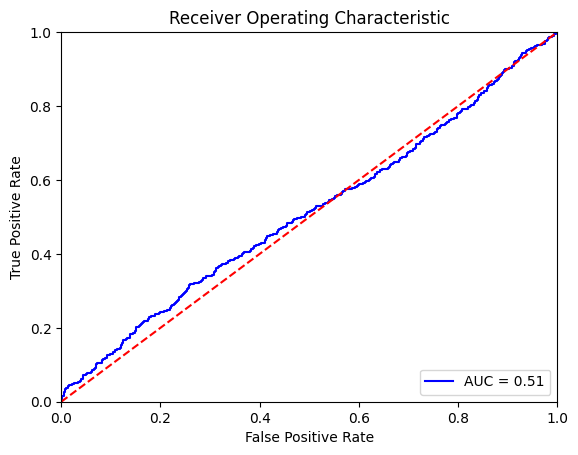

In [39]:
import sklearn.metrics as metrics
# calculate the fpr and tpr for all thresholds of the classification
fpr, tpr, threshold = metrics.roc_curve(y_test, y_pred_proba)
roc_auc = metrics.auc(fpr, tpr)

# method I: plt
import matplotlib.pyplot as plt
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [40]:
X_test_results

,<OPEN>,<HIGH>,<LOW>,<CLOSE>,<TICKVOL>,<SPREAD>,time,RSI,MACD,MACD_Signal,...,Return_22,Return_23,Return_24,Return_25,Return_26,Return_27,Return_28,Return_29,predicted,actual
datetime,,,,,,,,,,,,,,,,,,,,,
2023-01-06 01:00:00,1.08412,1.08571,1.08398,1.08434,11477,21,1,50.528346,-0.000104,0.000027,...,0.000590,-0.002062,0.000221,0.000442,-0.000552,0.000608,-0.000184,0.000193,0.012612,False
2023-01-06 02:00:00,1.08434,1.08550,1.08387,1.08479,6447,21,2,52.849327,-0.000046,0.000013,...,0.000553,0.000590,-0.002062,0.000221,0.000442,-0.000552,0.000608,-0.000184,0.009239,False
2023-01-06 03:00:00,1.08479,1.08490,1.08356,1.08469,4437,21,3,52.262543,-0.000008,0.000009,...,-0.000433,0.000553,0.000590,-0.002062,0.000221,0.000442,-0.000552,0.000608,0.003217,False
2023-01-06 04:00:00,1.08469,1.08516,1.08370,1.08453,4719,21,4,51.281466,0.000010,0.000009,...,-0.000065,-0.000433,0.000553,0.000590,-0.002062,0.000221,0.000442,-0.000552,0.005084,False
2023-01-06 05:00:00,1.08453,1.08552,1.08363,1.08370,5689,21,5,46.413983,-0.000043,-0.000002,...,0.000433,-0.000065,-0.000433,0.000553,0.000590,-0.002062,0.000221,0.000442,0.003865,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-31 08:00:00,1.10026,1.10035,1.09982,1.10012,2685,11,8,49.882152,0.000291,0.000359,...,-0.000055,0.000364,0.000218,0.000127,-0.000309,0.000055,0.000728,0.000282,0.001242,False
2025-03-31 09:00:00,1.10012,1.10032,1.09926,1.09927,4484,11,9,43.080062,0.000176,0.000323,...,0.000836,-0.000055,0.000364,0.000218,0.000127,-0.000309,0.000055,0.000728,0.000682,False
2025-03-31 10:00:00,1.09927,1.09999,1.09895,1.09992,5043,11,10,48.826770,0.000135,0.000285,...,-0.000218,0.000836,-0.000055,0.000364,0.000218,0.000127,-0.000309,0.000055,0.000723,False


In [41]:
for cutoff in range(0, 100):
    df = X_test_results[X_test_results['predicted']>cutoff/100.0]['actual'].value_counts(normalize=True)
    print(cutoff/100.0, " ", df[df.index == True].values)

0.0   [0.03006649]
0.01   [0.04536082]
0.02   [0.09677419]
0.03   [0.11392405]
0.04   [0.10909091]
0.05   [0.14634146]
0.06   [0.15625]
0.07   [0.2]
0.08   [0.21052632]
0.09   [0.22222222]
0.1   [0.1875]
0.11   [0.18181818]
0.12   [0.2]
0.13   [0.11111111]
0.14   [0.14285714]
0.15   [0.16666667]
0.16   [0.2]
0.17   [0.25]
0.18   [0.33333333]
0.19   [0.33333333]
0.2   [0.33333333]
0.21   [0.33333333]
0.22   [1.]
0.23   [1.]
0.24   [1.]
0.25   [1.]
0.26   [1.]
0.27   [1.]
0.28   [1.]
0.29   [1.]
0.3   [1.]
0.31   [1.]
0.32   [1.]
0.33   [1.]
0.34   [1.]
0.35   [1.]
0.36   [1.]
0.37   [1.]
0.38   [1.]
0.39   [1.]
0.4   [1.]
0.41   [1.]
0.42   [1.]
0.43   [1.]
0.44   [1.]
0.45   [1.]
0.46   [1.]
0.47   [1.]
0.48   [1.]
0.49   [1.]
0.5   [1.]
0.51   [1.]
0.52   [1.]
0.53   []
0.54   []
0.55   []
0.56   []
0.57   []
0.58   []
0.59   []
0.6   []
0.61   []
0.62   []
0.63   []
0.64   []
0.65   []
0.66   []
0.67   []
0.68   []
0.69   []
0.7   []
0.71   []
0.72   []
0.73   []
0.74   []
0.75   []


In [88]:
X_test_results[X_test_results['predicted']>0.5]

,<OPEN>,<HIGH>,<LOW>,<CLOSE>,<TICKVOL>,<SPREAD>,RSI,MACD,MACD_Signal,MACD_Hist,...,Return_22,Return_23,Return_24,Return_25,Return_26,Return_27,Return_28,Return_29,predicted,actual
Date,,,,,,,,,,,,,,,,,,,,,
2023-03-28,1.07279,1.07448,1.07077,1.07276,74128,21,42.942061,-0.004352,-0.004575,0.000223,...,-0.002342,-0.000805,-0.007946,-0.001937,0.003151,0.001911,0.000064,-0.002641,0.56,False
2023-06-07,1.09748,1.10311,1.09647,1.10179,88102,21,74.015750,0.006069,0.002408,0.003660,...,-0.003694,0.006279,-0.004857,-0.002320,-0.001805,0.005462,-0.008430,-0.000621,0.51,False
